In [1]:
import os 
import sys 
import re 
import yaml
import inspect 
import numpy as np 
import pandas as pd
import xarray as xr
from collections import defaultdict
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

In [15]:
pd.set_option('display.max_rows', 200, 'display.min_rows', 200, 'display.max_columns', None)

In [16]:
# load file for all dates
all_days_filepath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_30min/all_CSL_MobileLab_Parked_rev30minv4.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.reset_index(inplace=True)
df_alldays.set_index('time_local', inplace=True, drop=False)
df_alldays['USOS O3'] = df_alldays['O3_ppbv']
display(df_alldays['USOS O3'])
#adds padding of NaNs for first day and last day of campaign, since they need to have the same length of time as the other days in order to plot
new_start_time = pd.Timestamp('2024-07-14 00:00:00')
new_end_time = pd.Timestamp('2024-08-18 23:00:00')

# Create a new datetime index from new_start to the end of existing index with same frequency
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='1h')

# Reindex the dataframe to include new rows
df_alldays = df_alldays.reindex(new_index)
# Now df_expanded has rows starting at 00:00 with NaNs for the new rows

time_local
2024-07-14 18:00:00          NaN
2024-07-14 18:30:00          NaN
2024-07-14 19:00:00          NaN
2024-07-14 19:30:00          NaN
2024-07-14 20:00:00          NaN
2024-07-14 20:30:00          NaN
2024-07-14 21:00:00          NaN
2024-07-14 21:30:00          NaN
2024-07-14 22:00:00          NaN
2024-07-14 22:30:00          NaN
2024-07-14 23:00:00          NaN
2024-07-14 23:30:00          NaN
2024-07-15 00:00:00          NaN
2024-07-15 00:30:00          NaN
2024-07-15 01:00:00          NaN
2024-07-15 01:30:00          NaN
2024-07-15 02:00:00          NaN
2024-07-15 02:30:00          NaN
2024-07-15 03:00:00          NaN
2024-07-15 03:30:00          NaN
2024-07-15 04:00:00          NaN
2024-07-15 04:30:00          NaN
2024-07-15 05:00:00          NaN
2024-07-15 05:30:00          NaN
2024-07-15 06:00:00          NaN
2024-07-15 06:30:00          NaN
2024-07-15 07:00:00          NaN
2024-07-15 07:30:00          NaN
2024-07-15 08:00:00          NaN
2024-07-15 08:30:00          NaN

In [17]:
display(df_alldays['USOS O3'])

2024-07-14 00:00:00          NaN
2024-07-14 01:00:00          NaN
2024-07-14 02:00:00          NaN
2024-07-14 03:00:00          NaN
2024-07-14 04:00:00          NaN
2024-07-14 05:00:00          NaN
2024-07-14 06:00:00          NaN
2024-07-14 07:00:00          NaN
2024-07-14 08:00:00          NaN
2024-07-14 09:00:00          NaN
2024-07-14 10:00:00          NaN
2024-07-14 11:00:00          NaN
2024-07-14 12:00:00          NaN
2024-07-14 13:00:00          NaN
2024-07-14 14:00:00          NaN
2024-07-14 15:00:00          NaN
2024-07-14 16:00:00          NaN
2024-07-14 17:00:00          NaN
2024-07-14 18:00:00          NaN
2024-07-14 19:00:00          NaN
2024-07-14 20:00:00          NaN
2024-07-14 21:00:00          NaN
2024-07-14 22:00:00          NaN
2024-07-14 23:00:00          NaN
2024-07-15 00:00:00          NaN
2024-07-15 01:00:00          NaN
2024-07-15 02:00:00          NaN
2024-07-15 03:00:00          NaN
2024-07-15 04:00:00          NaN
2024-07-15 05:00:00          NaN
2024-07-15

In [30]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

udaq_o3_filepath = dirpath + 'Hawthorne_data/hawthorne_udaq_o3_2024.csv'
df_udaq_o3_load = pd.read_csv(udaq_o3_filepath, index_col = 'Date')

index_series = pd.Series(df_udaq_o3_load.index)
index_fixed = index_series.apply(lambda x: x if ':' in x else f'{x} 00:00')
df_udaq_o3_load.index = pd.to_datetime(index_fixed, format='%m/%d/%Y %H:%M')

In [31]:
print(df_udaq_o3_load)

                        O3
Date                      
2024-07-16 00:00:00  0.046
2024-07-16 01:00:00  0.053
2024-07-16 02:00:00  0.050
2024-07-16 03:00:00  0.046
2024-07-16 04:00:00  0.041
2024-07-16 05:00:00  0.038
2024-07-16 06:00:00  0.037
2024-07-16 07:00:00  0.033
2024-07-16 08:00:00  0.044
2024-07-16 09:00:00  0.057
2024-07-16 10:00:00  0.065
2024-07-16 11:00:00  0.073
2024-07-16 12:00:00  0.075
2024-07-16 13:00:00  0.066
2024-07-16 14:00:00  0.062
2024-07-16 15:00:00  0.061
2024-07-16 16:00:00  0.062
2024-07-16 17:00:00  0.060
2024-07-16 18:00:00  0.054
2024-07-16 19:00:00  0.045
2024-07-16 20:00:00  0.048
2024-07-16 21:00:00  0.052
2024-07-16 22:00:00  0.053
2024-07-16 23:00:00  0.054
2024-07-17 00:00:00  0.053
2024-07-17 01:00:00  0.050
2024-07-17 02:00:00  0.049
2024-07-17 03:00:00  0.049
2024-07-17 04:00:00  0.161
2024-07-17 05:00:00  0.048
2024-07-17 06:00:00  0.046
2024-07-17 07:00:00  0.046
2024-07-17 08:00:00  0.048
2024-07-17 09:00:00  0.051
2024-07-17 10:00:00  0.058
2

In [32]:
df_udaq_o3_load = df_udaq_o3_load.rename(columns = {'O3':'UDAQ O3'})
df_udaq_o3_load['UDAQ O3'] = df_udaq_o3_load['UDAQ O3']*1000
df_udaq_o3_load['UDAQ O3'] = df_udaq_o3_load['UDAQ O3'].where(df_udaq_o3_load['UDAQ O3'] <= 120)
display(df_udaq_o3_load)

,UDAQ O3
Date,
2024-07-16 00:00:00,46.0
2024-07-16 01:00:00,53.0
2024-07-16 02:00:00,50.0
2024-07-16 03:00:00,46.0
2024-07-16 04:00:00,41.0
2024-07-16 05:00:00,38.0
2024-07-16 06:00:00,37.0
2024-07-16 07:00:00,33.0
2024-07-16 08:00:00,44.0


In [33]:
df_ozone = pd.concat([df_udaq_o3_load['UDAQ O3'], df_alldays['USOS O3']], axis=1)
# df_ozone.index = date_index
df_ozone['merged_ozone'] = df_ozone['USOS O3'].combine_first(df_ozone['UDAQ O3'])
display(df_ozone)

,UDAQ O3,USOS O3,merged_ozone
2024-07-14 00:00:00,NaN,NaN,NaN
2024-07-14 01:00:00,NaN,NaN,NaN
2024-07-14 02:00:00,NaN,NaN,NaN
2024-07-14 03:00:00,NaN,NaN,NaN
2024-07-14 04:00:00,NaN,NaN,NaN
2024-07-14 05:00:00,NaN,NaN,NaN
2024-07-14 06:00:00,NaN,NaN,NaN
2024-07-14 07:00:00,NaN,NaN,NaN
2024-07-14 08:00:00,NaN,NaN,NaN
2024-07-14 09:00:00,NaN,NaN,NaN


Text(0.5, 1.0, 'Ozone Comparison')

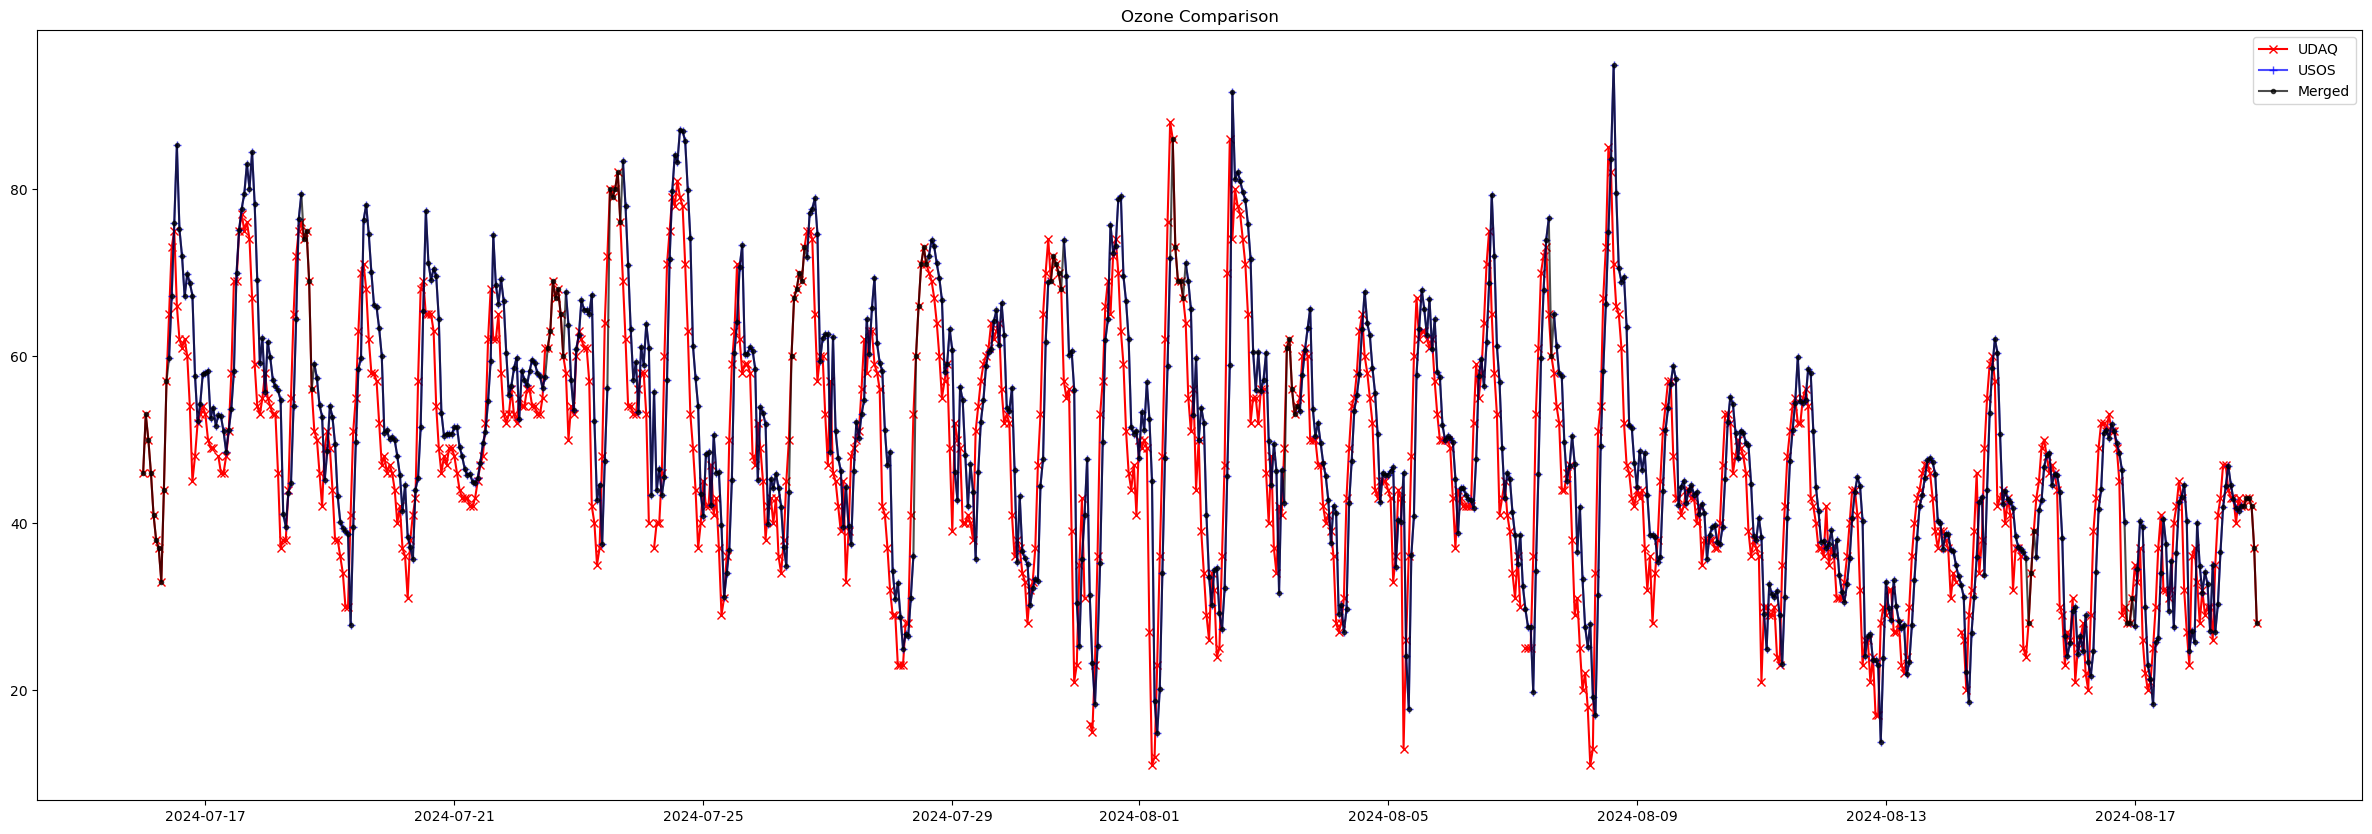

In [35]:
# Plot it so we can take a look at it... 
fig, ax = plt.subplots(figsize = (30,10))
ax.plot(df_ozone.index, df_ozone['UDAQ O3'], linestyle = 'solid', color = 'r', marker = 'x', label = 'UDAQ')
ax.plot(df_ozone.index, df_ozone['USOS O3'], linestyle = 'solid', color='b', marker='+',label='USOS', alpha = 0.7)
ax.plot(df_ozone.index, df_ozone['merged_ozone'], linestyle = 'solid', color='k', marker='.', label='Merged', alpha = 0.7)
plt.legend()
plt.title('Ozone Comparison')